In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path
from jax import pmap
from flax.jax_utils import replicate
from flax.training.common_utils import shard
from PIL import Image
from huggingface_hub import notebook_login
import diffusers
from src.pipeline_flax_stable_diffusion import FlaxToyDiffusionPipeline

In [2]:
num_devices = jax.device_count()
device_type = jax.devices()[0].device_kind
print(f"Found {num_devices} JAX devices of type {device_type}.")
assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
dtype = jnp.float32
pipeline, params = FlaxToyDiffusionPipeline.from_pretrained("sd-mnist")
params = replicate(params)

The config attributes {'safety_checker': [None, None]} were passed to FlaxToyDiffusionPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'safety_checker': [None, None]} are not expected by FlaxToyDiffusionPipeline and will be ignored.


Found 8 JAX devices of type TPU v3.


In [3]:
num_inference_steps = 50
prng_seed = jax.random.PRNGKey(23)
prng_seed = jax.random.split(prng_seed, num_devices)
batch_size = 1
images = pipeline(batch_size, params, prng_seed, num_inference_steps,height=32,width=32,jit=True).images


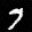

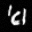

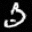

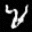

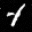

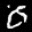

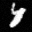

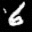

In [4]:
images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_devices*batch_size,) + images.shape[-3:])))

for image in images:
    display(image)

In [4]:
import jax
import jax.numpy as jnp
from functools import partial
import flax.linen as nn

# # prototype: split the first dimension as the Tai-Chi dimension
# @partial(jax.jit, static_argnames=['channel_axis','variant','eps'],)
# def colu(x, channel_axis = -3, variant = "soft", half_axis = False, eps = 1e-7):
#     if channel_axis == -3: # NCHW
#         x1, x_1 = x[...,:1,:,:], x[...,1:,:,:]
#     elif channel_axis == -1: # NC
#         x1, x_1 = x[...,:1], x[...,1:]
#     else:
#         raise NotImplementedError("channel_axis must be -1 or -3.")
    
#     x_1n = jnp.linalg.norm(x_1,axis=channel_axis,keepdims=True) # per-token norm
#     mask = x1 / (x_1n + eps)
#     print(x_1n)

#     if variant == "soft": # soft project
#         scaled_mask = nn.sigmoid(mask)
#     elif variant == "hard": # hard project
#         scaled_mask = mask > 0
#     else:
#         raise NotImplementedError("variant must be soft or hard.")

#     if half_axis: # single-sided cone
#         x1 = nn.relu(x1)

#     return jnp.concatenate([x1,scaled_mask*x_1],axis=channel_axis)

# x = jnp.zeros((1,3,1,2)) # two 3D tokens
# x = x.at[0,0,0,0].set(-10)
# x = x.at[0,1,0,0].set(-1)
# x = x.at[0,0,0,1].set(10)
# x = x.at[0,1,0,1].set(2)
# # x = [(-10,-1,0) (10,1,0)]
# print(colu(x, variant = "soft"))
# print(colu(x, variant = "hard", half_axis=True))

# The Ba-Gua idea: multi-cone topology, feeding input y as the axes. CF: adaptive group normalization (trivial-case reduction)
@partial(jax.jit, static_argnames=['channel_axis','variant','eps'],)
def group_colu(x, channel_axis = -3, variant = "soft", eps = 1e-7):
    num_channels = x.shape[channel_axis]
    y, x = x.take(jnp.arange(32), axis=channel_axis), x.take(jnp.arange(32,num_channels), axis=channel_axis)
    num_channels = x.shape[channel_axis]
    num_groups = y.shape[channel_axis] # number of cones
    assert num_channels % num_groups == 0, "Input must be a multiple of number of cones"
    group_size = num_channels // num_groups # S = C / G

    assert channel_axis < 0, "channel_axis must be negative" # Comply with broadcasting on first dimensions

    x_old_shape = x.shape
    y_old_shape = y.shape
    x_shape = x.shape[:channel_axis] + (num_groups, group_size)
    y_shape = y.shape[:channel_axis] + (num_groups, 1)
    if channel_axis < -1:
        x_shape += x.shape[(channel_axis+1):] # NGSHW if channel_axis = -3
        y_shape += y.shape[(channel_axis+1):] # NG1HW
    x = x.reshape(x_shape)
    y = y.reshape(y_shape)

    xn = jnp.linalg.norm(x,axis=channel_axis,keepdims=True) # NG1HW, per-group norm, or the S dimension

    mask = y / (xn + eps) # NG1HW

    if variant == "soft": # soft project
        scaled_mask = nn.sigmoid(mask-.5)
    elif variant == "hard": # hard project
        scaled_mask = mask.clip(0,1)
    else:
        raise NotImplementedError("variant must be soft or hard.")

    x = scaled_mask * x # NGSHW

    x = x.reshape(x_old_shape)
    y = y.reshape(y_old_shape)

    return jnp.concatenate([y,x],axis=channel_axis)

x = jnp.zeros((1,320)) # comply with GroupNorm(32)
# y = jnp.ones((1,32,1,2))
x = x.at[0,0,].set(1)
# [y x] = (-10,0,0,...)
x1 = group_colu(x, variant="soft",channel_axis=-1)
print(x1.shape)
# x1[0,:3,0,0]


UnboundLocalError: local variable 'y_shape' referenced before assignment

In [19]:
jnp.arange(32,64)

Array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
       49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63],      dtype=int32)

In [24]:
jnp.zeros((3,320,2,2)).take( jnp.arange(32), axis=-3).shape



(3, 32, 2, 2)